# Hetero aggregate based on deposition driven KMC

The purpose of this notebook is to propose a proof of concept model for later parameterization of heteraggregate clusters resulting from the FSP process by using the CFD field data to track Lagrangian fluid parcels of aggregates being formed.

It is strongly based on Arrhenius rate laws for modelling the relative nucleation rates of two primary particles:

$$r_A = k_A e^{-Ea_A/R T} C_A^{n_A}$$

$$r_B = k_B e^{-Ea_B/R T} C_B^{n_B}$$

The core simplifying MC assumption is that relative rates determine statistical order of nucleation which in turn can be used to compute the one way coupled formation of particles in a tracked fluid parcel. Additional assumptions that can be changed later

- Diffusion rate based on a mean temperature and diffusion rate for the film generation.
- Total nucleation rates are distributed based on the one way coupled results of the temperature profile and the order of deposited particles in the final aggregate film.
- Particle size distributions are based on the fitted data only.
- Nucleation starts just after the temperature peak (NOTE: Need to re-read the mechanisms in the 2015 Eggersdorfer paper.
- D_f ~ 2.13 for 30 deg and 2.05 for 20 deg
- Mean hetero coordination number ~ 0.4
- Mean homo coordination number ~ 4.0
- Mean coordination number total homo- and hetero contacts /total particles (the number of particle contacts with particles of the same or the different material divided by all particles)

TODO:
- Get the particle size distribution
- Cluster size?

## Data imports and parameters
### CFD field data imports

Loaded 156 streamlines total


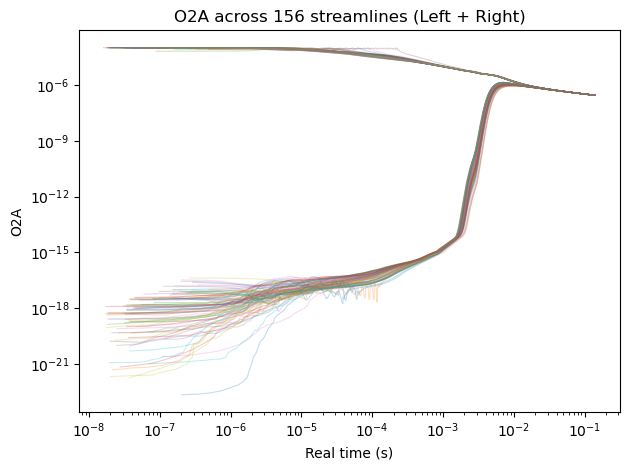

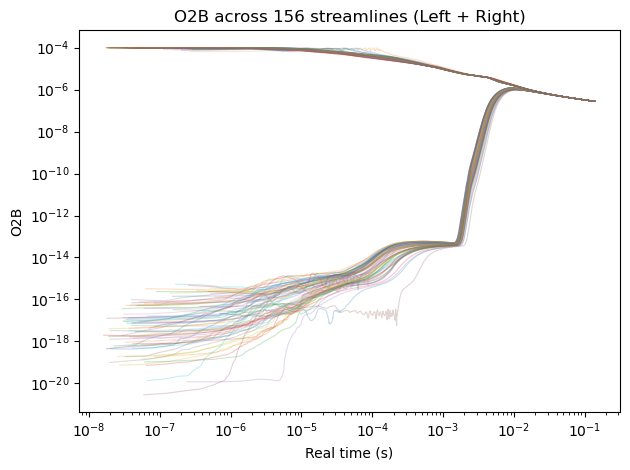

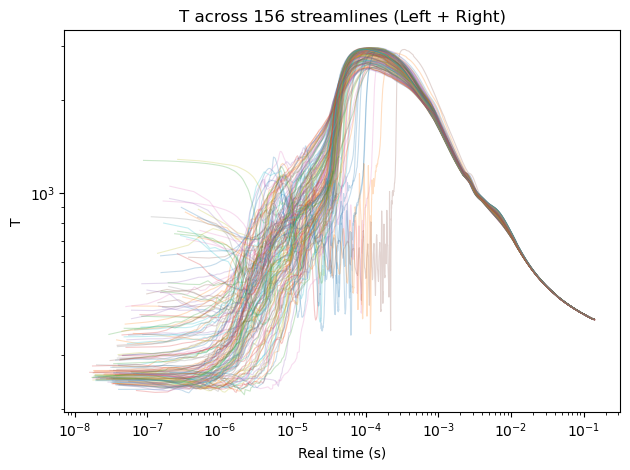

In [1]:
import os, glob, csv, math
import matplotlib.pyplot as plt
import polyscope as ps

# ------------------------------------------------------------------
# 1.  Tell the script where to look
# ------------------------------------------------------------------
base_dirs = [
    "./case_studies/hetero/Streamline_PBE/DFSP_30_150_Streamline_Left/processed",
    "./case_studies/hetero/Streamline_PBE/DFSP_30_150_Streamline_Right/processed",
]

streamlines = {}          # {global_idx: {col: [values,…]}}
global_idx  = 0           # will increment for every file we load

# ------------------------------------------------------------------
# 2.  Walk through every directory → every file
# ------------------------------------------------------------------
for base in base_dirs:
    pattern = os.path.join(base, "processed_streamline_*.csv")
    for fp in sorted(glob.glob(pattern)):          # keep a stable order
        with open(fp, newline='') as f:
            reader = csv.DictReader(f)
            data   = {h: [] for h in reader.fieldnames}
            for row in reader:
                for h in reader.fieldnames:
                    try:
                        data[h].append(float(row[h]))
                    except (ValueError, TypeError):
                        data[h].append(math.nan)

        streamlines[global_idx] = data
        global_idx += 1

print(f"Loaded {len(streamlines)} streamlines total")

# ------------------------------------------------------------------
# 3.  Quick visual confirmation (same as before)
# ------------------------------------------------------------------
plot_keys = ["O2A", "O2B", "T"]
time_key  = "IntegrationTime"

for key in plot_keys:
    plt.figure()
    for idx in sorted(streamlines):
        d = streamlines[idx]
        plt.loglog(d[time_key], d[key], alpha=0.25, linewidth=0.8)
    plt.xlabel("Real time (s)")
    plt.ylabel(key)
    plt.title(f"{key} across {len(streamlines)} streamlines (Left + Right)")
    plt.tight_layout()

plt.show()


### Util funcs

In [2]:
def compute_contact_stats(
        pos_A, pos_B,                # (NA,3)  & (NB,3)
        rad_A, rad_B,                # (NA,)   & (NB,)
        tol      = 0.01,             # fractional slack on touch distance
        block_sz = 4096              # tune if memory is tight
    ):
    """
    Returns:
        homo_contacts, hetero_contacts, coord_homo, coord_hetero
    (See earlier doc-string for full description.)
    """
    # ------------------------------------------------------------------
    # 0.  Merge arrays for easier indexing
    # ------------------------------------------------------------------
    pos   = np.vstack([pos_A, pos_B])
    radii = np.hstack([rad_A, rad_B])
    ptype = np.hstack([np.zeros(len(pos_A), dtype=np.int8),
                       np.ones (len(pos_B), dtype=np.int8)])
    N     = len(radii)

    homo_contacts   = 0
    hetero_contacts = 0
    coord_homo      = np.zeros(N, dtype=np.uint32)
    coord_hetero    = np.zeros(N, dtype=np.uint32)

    # ------------------------------------------------------------------
    # 1.  Pair search – inter-block **and** intra-block
    # ------------------------------------------------------------------
    for lo in range(0, N, block_sz):
        hi = min(lo + block_sz, N)

        # --------------------------------------------------------------
        # 1a.  Pairs where j ≥ hi   (different blocks)   ← as before
        # --------------------------------------------------------------
        if hi < N:                                        # skip if last block
            P_block   = pos[lo:hi]
            radii_blk = radii[lo:hi][:, None]

            diff   = pos[hi:] - P_block[:, None, :]
            dist2  = np.sum(diff**2, axis=-1)
            sum_r  = radii_blk + radii[hi:]
            thresh2 = (sum_r * (1.0 + tol))**2

            ii, jj = np.where(dist2 <= thresh2)
            i_idx  = lo + ii
            j_idx  = hi + jj

            same = (ptype[i_idx] == ptype[j_idx])
            homo_contacts   += int(np.count_nonzero(same))
            hetero_contacts += int(np.count_nonzero(~same))

            for a, b in zip(i_idx, j_idx):
                if same[np.where(i_idx==a)[0][0]]:
                    coord_homo[a]   += 1
                    coord_homo[b]   += 1
                else:
                    coord_hetero[a] += 1
                    coord_hetero[b] += 1

        # --------------------------------------------------------------
        # 1b.  Pairs *inside* [lo:hi)  (same block) – upper triangle
        # --------------------------------------------------------------
        if hi - lo > 1:                                   # need ≥2 points
            P_block   = pos[lo:hi]
            r_block   = radii[lo:hi]

            # full pairwise distances inside the block
            diff      = P_block[:, None, :] - P_block[None, :, :]
            dist2     = np.sum(diff**2, axis=-1)

            # radii sums matrix
            sum_r     = r_block[:, None] + r_block[None, :]
            thresh2   = (sum_r * (1.0 + tol))**2

            # keep only upper-triangle (k=1 removes diagonal)
            iu, ju = np.triu_indices(hi - lo, k=1)
            mask   = dist2[iu, ju] <= thresh2[iu, ju]
            if not np.any(mask):
                continue

            i_idx = lo + iu[mask]
            j_idx = lo + ju[mask]

            same = (ptype[i_idx] == ptype[j_idx])
            homo_contacts   += int(np.count_nonzero(same))
            hetero_contacts += int(np.count_nonzero(~same))

            for a, b in zip(i_idx, j_idx):
                if ptype[a] == ptype[b]:
                    coord_homo[a]   += 1
                    coord_homo[b]   += 1
                else:
                    coord_hetero[a] += 1
                    coord_hetero[b] += 1

    return homo_contacts, hetero_contacts, coord_homo, coord_hetero


### Load deposition based generated film

In [3]:
from classes.particlelayer import *
import numpy as np
import json
import polyscope as ps

file  = './case_studies/hetero/results/hetero.trj'
#file  = './case_studies/hetero/resultshetero.trj'
layer = particlelayer(file, nodescription=False).layer

# Shape
layer._data.shape

# Extract positions in space
points = np.zeros([layer.data.shape[0], 3])
points[:, 0] = layer.data[:, layer.lib['x']]
points[:, 1] = layer.data[:, layer.lib['y']]
points[:, 2] = layer.data[:, layer.lib['z']]
particles = points  # used later
# Extract the radius
radii  = np.zeros(layer.data.shape[0])
radii = layer.data[:, layer.lib['r']]

if 0:
    # Plot in polyscope
    ps.init()
    ps.set_up_dir("z_up")
    ps_cloud = ps.register_point_cloud("Particles", points)
    ps_cloud.add_scalar_quantity("Particle radii", radii)
    ps_cloud.set_point_radius_quantity("Particle radii", autoscale=False)
    ps_cloud.set_color((1.0, 1.0, 1.0))
    ps.show()


### Reading Particle Structure File
# Filename: ./case_studies/hetero/results/hetero.trj
    File ./case_studies/hetero/results/hetero.trj using units nano and type dda
# File Format: trj
# Units: nano
# Primary Particles: 2,000
# Aggregates: 19
# Box Width: 1.500e+02 x 1.500e+02
# Film Height: 2.974e+02
### Done


In [4]:
T = d['T']  # d is the last data set we used in the loop
t_n_start_i = np.argmax(T)
t_n_start_i = 0  # New code use all data
t_n_start_i, len(T)
T

[241.07,
 239.02,
 237.55,
 236.12,
 235.7,
 235.87,
 236.02,
 236.96,
 237.9,
 239.02,
 240.02,
 240.91,
 241.54,
 242.41,
 243.0,
 243.53,
 244.12,
 245.89,
 247.7,
 246.22,
 247.26,
 248.08,
 250.54,
 253.78,
 255.26,
 256.4,
 257.91,
 259.13,
 260.87,
 263.23,
 267.63,
 273.81,
 276.56,
 310.84,
 332.62,
 352.64,
 340.27,
 391.23,
 363.77,
 363.51,
 374.84,
 382.55,
 390.25,
 406.04,
 416.18,
 435.68,
 439.17,
 448.86,
 465.04,
 481.77,
 513.68,
 522.08,
 519.58,
 527.63,
 540.94,
 548.12,
 569.08,
 570.33,
 581.16,
 598.79,
 620.09,
 647.49,
 720.64,
 787.84,
 834.53,
 856.46,
 883.61,
 906.45,
 944.62,
 960.34,
 988.52,
 1011.5,
 1040.1,
 1068.4,
 1094.6,
 1121.4,
 1147.1,
 1168.8,
 1194.2,
 1229.7,
 1259.3,
 1299.9,
 1343.1,
 1402.7,
 1473.1,
 1593.2,
 1703.2,
 1836.1,
 1916.6,
 1998.1,
 2103.1,
 2177.2,
 2232.4,
 2285.2,
 2323.7,
 2361.2,
 2399.6,
 2431.5,
 2462.5,
 2491.2,
 2516.5,
 2539.9,
 2561.7,
 2582.2,
 2600.5,
 2617.5,
 2632.0,
 2646.7,
 2659.1,
 2671.0,
 2681.0,
 2691.

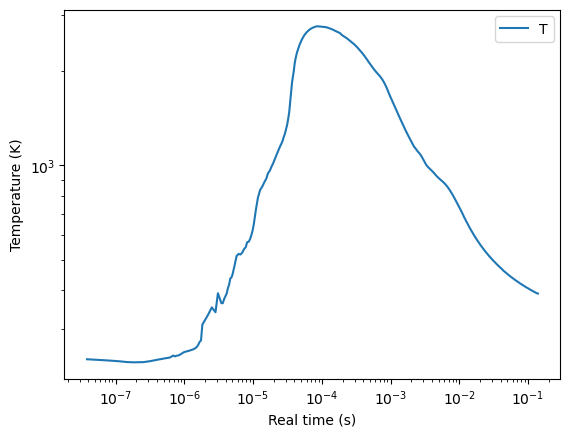

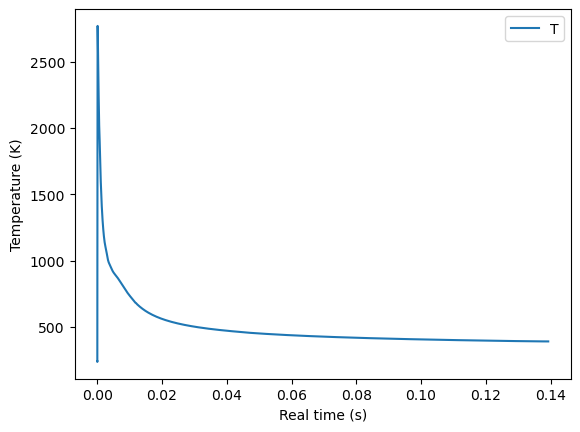

In [5]:
plt.figure()
plt.loglog(d['IntegrationTime'][t_n_start_i:], T[t_n_start_i:], label='T')
plt.ylabel('Temperature (K)')
plt.xlabel('Real time (s)')
plt.legend()
plt.figure()
plt.plot(d['IntegrationTime'][t_n_start_i:], T[t_n_start_i:], label='T')
plt.ylabel('Temperature (K)')
plt.xlabel('Real time (s)')
plt.legend()

|## Time discretisation

Here we determine the real time spent available for nucleation

In [6]:
# Analytical solutions of mean coordination numbers:
homo_cn_anal = 4.0
#>>> 4.0**(2/3)  # 2D --> 3D
#2.5198420997897464
homo_cn_anal = 2.5198420997897464
heter_cn_anal = 0.4
#>>> 0.4**(2/3)  # 2D --> 3D
#0.5428835233189814
heter_cn_anal = 0.5428835233189814

# Define KMC rate laws and parameters
# Parameters (to be optimized)
k_A = 1  #  Arrhenius prefactor for compound A
k_B = 1  #  Arrhenius prefactor for compound B
Ea_A = 1  # Activation energy for compound A (should be based on nucleation)
Ea_B = 1  # Activation energy for compound B (should be based on nucleation)

# Parameters (fixed)
n_A = 1  # Rate law order of compound A
n_B = 1  # Rate law order of compound B
R = 8.314  # Universal gas constant J kmol-1 K-1

# Rate law
def r_i(c, T, k, E):
    return k * np.exp(-E / (R * T)) * c

obj = 0.0
for idx in sorted(streamlines):
    # Time discretisation (here we determine the real time spent available for nucleation)
    d = streamlines[idx]
    tn = np.array(d['IntegrationTime'][t_n_start_i:]) - np.array(d['IntegrationTime'][t_n_start_i])  # time - starting time
    Tn = np.array(d['T'][t_n_start_i:])
    CA_n = np.array(d['O2A'][t_n_start_i:])
    CB_n = np.array(d['O2B'][t_n_start_i:])
    #if Tn.shape[0] > CA_n.shape[0]:
    #    CA_n = np.array(d['O2A'][t_n_start_i:Tn.shape[0]])
    #elif CA_n.shape[0] < Tn.shape[0]:
    #    CA_n = np.array(d['O2A'][t_n_start_i:Tn.shape[0]])
    #CB_n = np.array(d['O2B'][t_n_start_i:Tn.shape[0]])

    # Usable values (print in debugging:
    #np.sum(tn), len(tn), len(Tn), len(CA_n), len(CB_n)
    #particles.shape[0]/len(tn)

    # Assume even split for now (nucleation rates probably based on cooling rate, which is relatively linear?
    p_formed = np.zeros_like(tn)  # Number of particles nucleated at every time step
    p_formed[:] = int(particles.shape[0]/len(tn)) # Can be modified here later for more realistic distributions.
    p_formed[-1] =  particles.shape[0] - np.sum(p_formed[:-1])
    #p_formed, np.sum(p_formed)

    # Reaction rates
    r_A_range = r_i(CA_n, Tn, k_A, Ea_A)
    r_B_range = r_i(CB_n, Tn, k_B, Ea_A)
    r_t = r_A_range + r_B_range
    # KMC relative formation rates
    ra = r_A_range / r_t
    rb = r_B_range / r_t
    #ra, rb

    # Main nucleation loop
    # The logic is that each time step we used the KMC rates derived above to
    # find the nucleating particles each time step
    particles_A_i = []  # Indices of particle A
    particles_B_i = []  # Indices of particle B
    # KMC formation each time step
    particles_i = 0  # current particle index tracker
    for i, pf in enumerate(p_formed):
        for pi in range(int(pf)):
            # Distributed in kmc ration
            if np.random.rand() < ra[i]:
                particles_A_i.append(particles_i)
            else:
                particles_B_i.append(particles_i)

            particles_i += 1  # Current particle index

    # Post processing:
    Particles_A = particles[particles_A_i]
    Particles_B = particles[particles_B_i]
    radii_A = radii[particles_A_i]
    radii_B = radii[particles_B_i]
    # Compute contacts
    hc, hetc, c_homo, c_hetero = compute_contact_stats(
        Particles_A, Particles_B, radii_A, radii_B)   # try 10 % slack
    # Compute mean coordination numbers
    homo_cn = hc / (Particles_A.shape[0] + Particles_B.shape[0])
    heter_cn = hetc / (Particles_A.shape[0] + Particles_B.shape[0])
    #print(f'homo_cn = {homo_cn}')
    #print(f'heter_cn = {heter_cn}')
    # Compute obj by norm to experimental values
    obj += np.linalg.norm(homo_cn - homo_cn_anal) + np.linalg.norm(heter_cn - heter_cn_anal)

len(particles_A_i), len(particles_B_i)
print(f'obj = {obj}')

obj = 532.0380000000013


# Objective function definition

In [7]:
import numpy as np

# Assumed globals (you must ensure these are defined before optimization)
# - streamlines: dict of streamlines with keys 'IntegrationTime', 'T', 'O2A', 'O2B'
# - particles: ndarray of particle positions
# - radii: ndarray of particle radii
# - t_n_start_i: int, start index for nucleation time
# - compute_contact_stats: function(Particles_A, Particles_B, radii_A, radii_B)

def objective(params, homo_cn_anal=0.7, heter_cn_anal=0.25, n_A=1,  n_B=1):
    # Unpack optimization parameters
    k_A, k_B, Ea_A, Ea_B = params
    #k_A, k_B, Ea_A, Ea_B, n_A, n_B  = params

    # Fixed parameters (note, not actually added to equations yet)
    n_A = n_A
    n_B = n_B
    R = 8.314  # Universal gas constant

    # Analytical target coordination numbers
    homo_cn_anal = homo_cn_anal # homo_cn_anal 2D = 4.0
    heter_cn_anal = heter_cn_anal # heter_cn_anal = 0.4

    # Rate law function
    def r_i(c, T, k, E):
        return k * np.exp(-E / (R * T)) * c

    # Objective value
    obj = 0.0

    for idx in sorted(streamlines):
        d = streamlines[idx]

        tn = np.array(d['IntegrationTime'][t_n_start_i:]) - d['IntegrationTime'][t_n_start_i]
        Tn = np.array(d['T'][t_n_start_i:])
        CA_n = np.array(d['O2A'][t_n_start_i:])
        CB_n = np.array(d['O2B'][t_n_start_i:])

        # Nucleation event distribution
        p_formed = np.zeros_like(tn, dtype=int)
        p_formed[:] = int(particles.shape[0] / len(tn))
        p_formed[-1] = particles.shape[0] - np.sum(p_formed[:-1])

        # Reaction rates
        r_A_range = r_i(CA_n, Tn, k_A, Ea_A)
        r_B_range = r_i(CB_n, Tn, k_B, Ea_B)
        r_t = r_A_range + r_B_range

        # Avoid divide-by-zero
        r_t[r_t == 0] = 1e-12
        ra = r_A_range / r_t
        rb = r_B_range / r_t

        # KMC particle assignment
        particles_A_i = []
        particles_B_i = []
        particles_i = 0
        for i, pf in enumerate(p_formed):
            for _ in range(int(pf)):
                if np.random.rand() < ra[i]:
                    particles_A_i.append(particles_i)
                else:
                    particles_B_i.append(particles_i)
                particles_i += 1

        Particles_A = particles[particles_A_i]
        Particles_B = particles[particles_B_i]
        radii_A = radii[particles_A_i]
        radii_B = radii[particles_B_i]

        hc, hetc, _, _ = compute_contact_stats(Particles_A, Particles_B, radii_A, radii_B)

        total_particles = Particles_A.shape[0] + Particles_B.shape[0]
        homo_cn = hc / total_particles if total_particles > 0 else 0
        heter_cn = hetc / total_particles if total_particles > 0 else 0

        obj += np.linalg.norm(homo_cn - homo_cn_anal) + np.linalg.norm(heter_cn - heter_cn_anal)

    return obj


# Run the optimization

In [1]:
from scipy.optimize import shgo

# Define bounds for each parameter: (k_A, k_B, Ea_A, Ea_B)
bounds = [
    (1e-3, 10000),  # k_A
    (1e-3, 10000),  # k_B
    (1e-3, 100000), # Ea_A
    (1e-3, 100000)  # Ea_B
]

#args=(homo_cn_anal=0.7, heter_cn_anal=0.25, n_A=1, n_B=1)
options = {'maxiter': 15000}
result = shgo(objective, bounds,
              n=10000,
              options=options,
              workers=16,  # ~4-10 hours
              )
print(result)

SyntaxError: unmatched '}' (149640525.py, line 12)

In [14]:
23/57*1000 /60

6.7251461988304095

# Visualize the results

Simply run the objective function code one more time to populate the `Particles_A`, `Particles_`, `radii_A` and `radii_B` variables.

In [9]:
# Define KMC rate laws and parameters
# Parameters (from the optimization routine)
k_A, k_B, Ea_A, Ea_B = res.x
#k_A, k_B, Ea_A, Ea_B = 1.000e+01,  1.000e+01,  1.000e-01,  1.000e+02
#1.000e+01  1.000e+01  1.000e-01  1.000e+02]
# Parameters (fixed)
n_A = 1  # Rate law order of compound A
n_B = 1  # Rate law order of compound B
R = 8.314  # Universal gas constant J kmol-1 K-1

# Rate law
def r_i(c, T, k, E):
    return k * np.exp(-E / (R * T)) * c

obj = 0.0
for idx in sorted(streamlines):
    # Time discretisation (here we determine the real time spent available for nucleation)
    d = streamlines[idx]
    tn = np.array(d['IntegrationTime'][t_n_start_i:]) - np.array(d['IntegrationTime'][t_n_start_i])  # time - starting time
    Tn = np.array(d['T'][t_n_start_i:])
    CA_n = np.array(d['O2A'][t_n_start_i:])
    CB_n = np.array(d['O2B'][t_n_start_i:])
    #if Tn.shape[0] > CA_n.shape[0]:
    #    CA_n = np.array(d['O2A'][t_n_start_i:Tn.shape[0]])
    #elif CA_n.shape[0] < Tn.shape[0]:
    #    CA_n = np.array(d['O2A'][t_n_start_i:Tn.shape[0]])
    #CB_n = np.array(d['O2B'][t_n_start_i:Tn.shape[0]])

    # Usable values (print in debugging:
    #np.sum(tn), len(tn), len(Tn), len(CA_n), len(CB_n)
    #particles.shape[0]/len(tn)

    # Assume even split for now (nucleation rates probably based on cooling rate, which is relatively linear?
    p_formed = np.zeros_like(tn)  # Number of particles nucleated at every time step
    p_formed[:] = int(particles.shape[0]/len(tn)) # Can be modified here later for more realistic distributions.
    p_formed[-1] =  particles.shape[0] - np.sum(p_formed[:-1])
    #p_formed, np.sum(p_formed)

    # Reaction rates
    r_A_range = r_i(CA_n, Tn, k_A, Ea_A)
    r_B_range = r_i(CB_n, Tn, k_B, Ea_A)
    r_t = r_A_range + r_B_range
    # KMC relative formation rates
    ra = r_A_range / r_t
    rb = r_B_range / r_t
    #ra, rb

    # Main nucleation loop
    # The logic is that each time step we used the KMC rates derived above to
    # find the nucleating particles each time step
    particles_A_i = []  # Indices of particle A
    particles_B_i = []  # Indices of particle B
    # KMC formation each time step
    particles_i = 0  # current particle index tracker
    for i, pf in enumerate(p_formed):
        for pi in range(int(pf)):
            # Distributed in kmc ration
            if np.random.rand() < ra[i]:
                particles_A_i.append(particles_i)
            else:
                particles_B_i.append(particles_i)

            particles_i += 1  # Current particle index

    # Post processing:
    Particles_A = particles[particles_A_i]
    Particles_B = particles[particles_B_i]
    radii_A = radii[particles_A_i]
    radii_B = radii[particles_B_i]
    # Compute contacts
    hc, hetc, c_homo, c_hetero = compute_contact_stats(
        Particles_A, Particles_B, radii_A, radii_B)   # try 10 % slack
    # Compute mean coordination numbers
    homo_cn = hc / (Particles_A.shape[0] + Particles_B.shape[0])
    heter_cn = hetc / (Particles_A.shape[0] + Particles_B.shape[0])
    #print(f'homo_cn = {homo_cn}')
    #print(f'heter_cn = {heter_cn}')
    # Compute obj by norm to experimental values
    obj += np.linalg.norm(homo_cn - homo_cn_anal) + np.linalg.norm(heter_cn - heter_cn_anal)

len(particles_A_i), len(particles_B_i)
print(f'obj = {obj}')

obj = 532.0380000000013


In [12]:
# Plot in polyscope
if 1:
    tab_red = (0.890, 0.102, 0.110)
    tab_blue = (0.122, 0.467, 0.706)
    tab_green = (0.173, 0.627, 0.173)

    ps.init()
    ps.set_up_dir("z_up")
    ps_cloud_A = ps.register_point_cloud("Particles A", Particles_A)
    ps_cloud_A.add_scalar_quantity("Particle A radii", radii_A)
    ps_cloud_A.set_color(tab_red)
    ps_cloud_B = ps.register_point_cloud("Particles B", Particles_B)
    ps_cloud_B.add_scalar_quantity("Particle B radii", radii_B)
    ps_cloud_B.set_color(tab_green)

    if 0:
        # Visualise per-particle coordination numbers in Polyscope
        ps_cloud_A.add_scalar_quantity("A homo coord.",   homo_cn[:len(Particles_A)])
        ps_cloud_A.add_scalar_quantity("A hetero coord.", heter_cn[:len(Particles_A)])
        ps_cloud_B.add_scalar_quantity("B homo coord.",   homo_cn[len(Particles_A):])
        ps_cloud_B.add_scalar_quantity("B hetero coord.", heter_cn[len(Particles_A):])
    #ps_cloud.set_point_radius_quantity("Particle radii", autoscale=False)
    ps.show()

In [11]:
import polyscope as ps

# Plot in polyscope
if 1:
    tab_red = (0.890, 0.102, 0.110)
    tab_blue = (0.122, 0.467, 0.706)
    tab_green = (0.173, 0.627, 0.173)

    ps.init()
    ps.set_up_dir("z_up")

    # Register Particles A
    ps_cloud_A = ps.register_point_cloud("Particles A", Particles_A)
    ps_cloud_A.add_scalar_quantity("Particle A radii", radii_A)
    ps_cloud_A.set_color(tab_red)
    ps_cloud_A.set_radius_quantity(radii_A, autoscale=False)

    # Register Particles B
    ps_cloud_B = ps.register_point_cloud("Particles B", Particles_B)
    ps_cloud_B.add_scalar_quantity("Particle B radii", radii_B)
    ps_cloud_B.set_color(tab_green)
    ps_cloud_B.set_radius_quantity(radii_B, autoscale=False)

    if 0:
        # Visualise per-particle coordination numbers in Polyscope
        ps_cloud_A.add_scalar_quantity("A homo coord.",   homo_cn[:len(Particles_A)])
        ps_cloud_A.add_scalar_quantity("A hetero coord.", heter_cn[:len(Particles_A)])
        ps_cloud_B.add_scalar_quantity("B homo coord.",   homo_cn[len(Particles_A):])
        ps_cloud_B.add_scalar_quantity("B hetero coord.", heter_cn[len(Particles_A):])

    ps.show()


AttributeError: 'PointCloud' object has no attribute 'set_radius_quantity'